## US-08 · Distribuzione delle Variabili Numeriche per Classe Churn

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

df = pd.read_csv('../data/processed/data_clean.csv')
print(df.shape)

(7043, 37)


In [36]:
print(df.columns.tolist())

['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'churn', 'cltv', 'contract', 'dependents', 'device_protection_plan', 'gender', 'internet_service', 'internet_type', 'married', 'monthly_charge', 'multiple_lines', 'num_dependents', 'num_referrals', 'offer', 'online_backup', 'online_security', 'paperless_billing', 'partner', 'payment_method', 'phone_service', 'population', 'premium_tech_support', 'referred_a_friend', 'senior_citizen', 'streaming_movies', 'streaming_music', 'streaming_tv', 'tenure_months', 'total_charges', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue', 'unlimited_data']


In [37]:
numeric_vars = [
    'monthly_charge',
    'tenure_months',
    'total_charges',
    'age',
    'avg_monthly_gb_download',
    'avg_monthly_ld_charges',
    'total_revenue',
    'total_refunds'
]

✅ Grafico salvato in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\us08_distribuzioni_numeriche.png


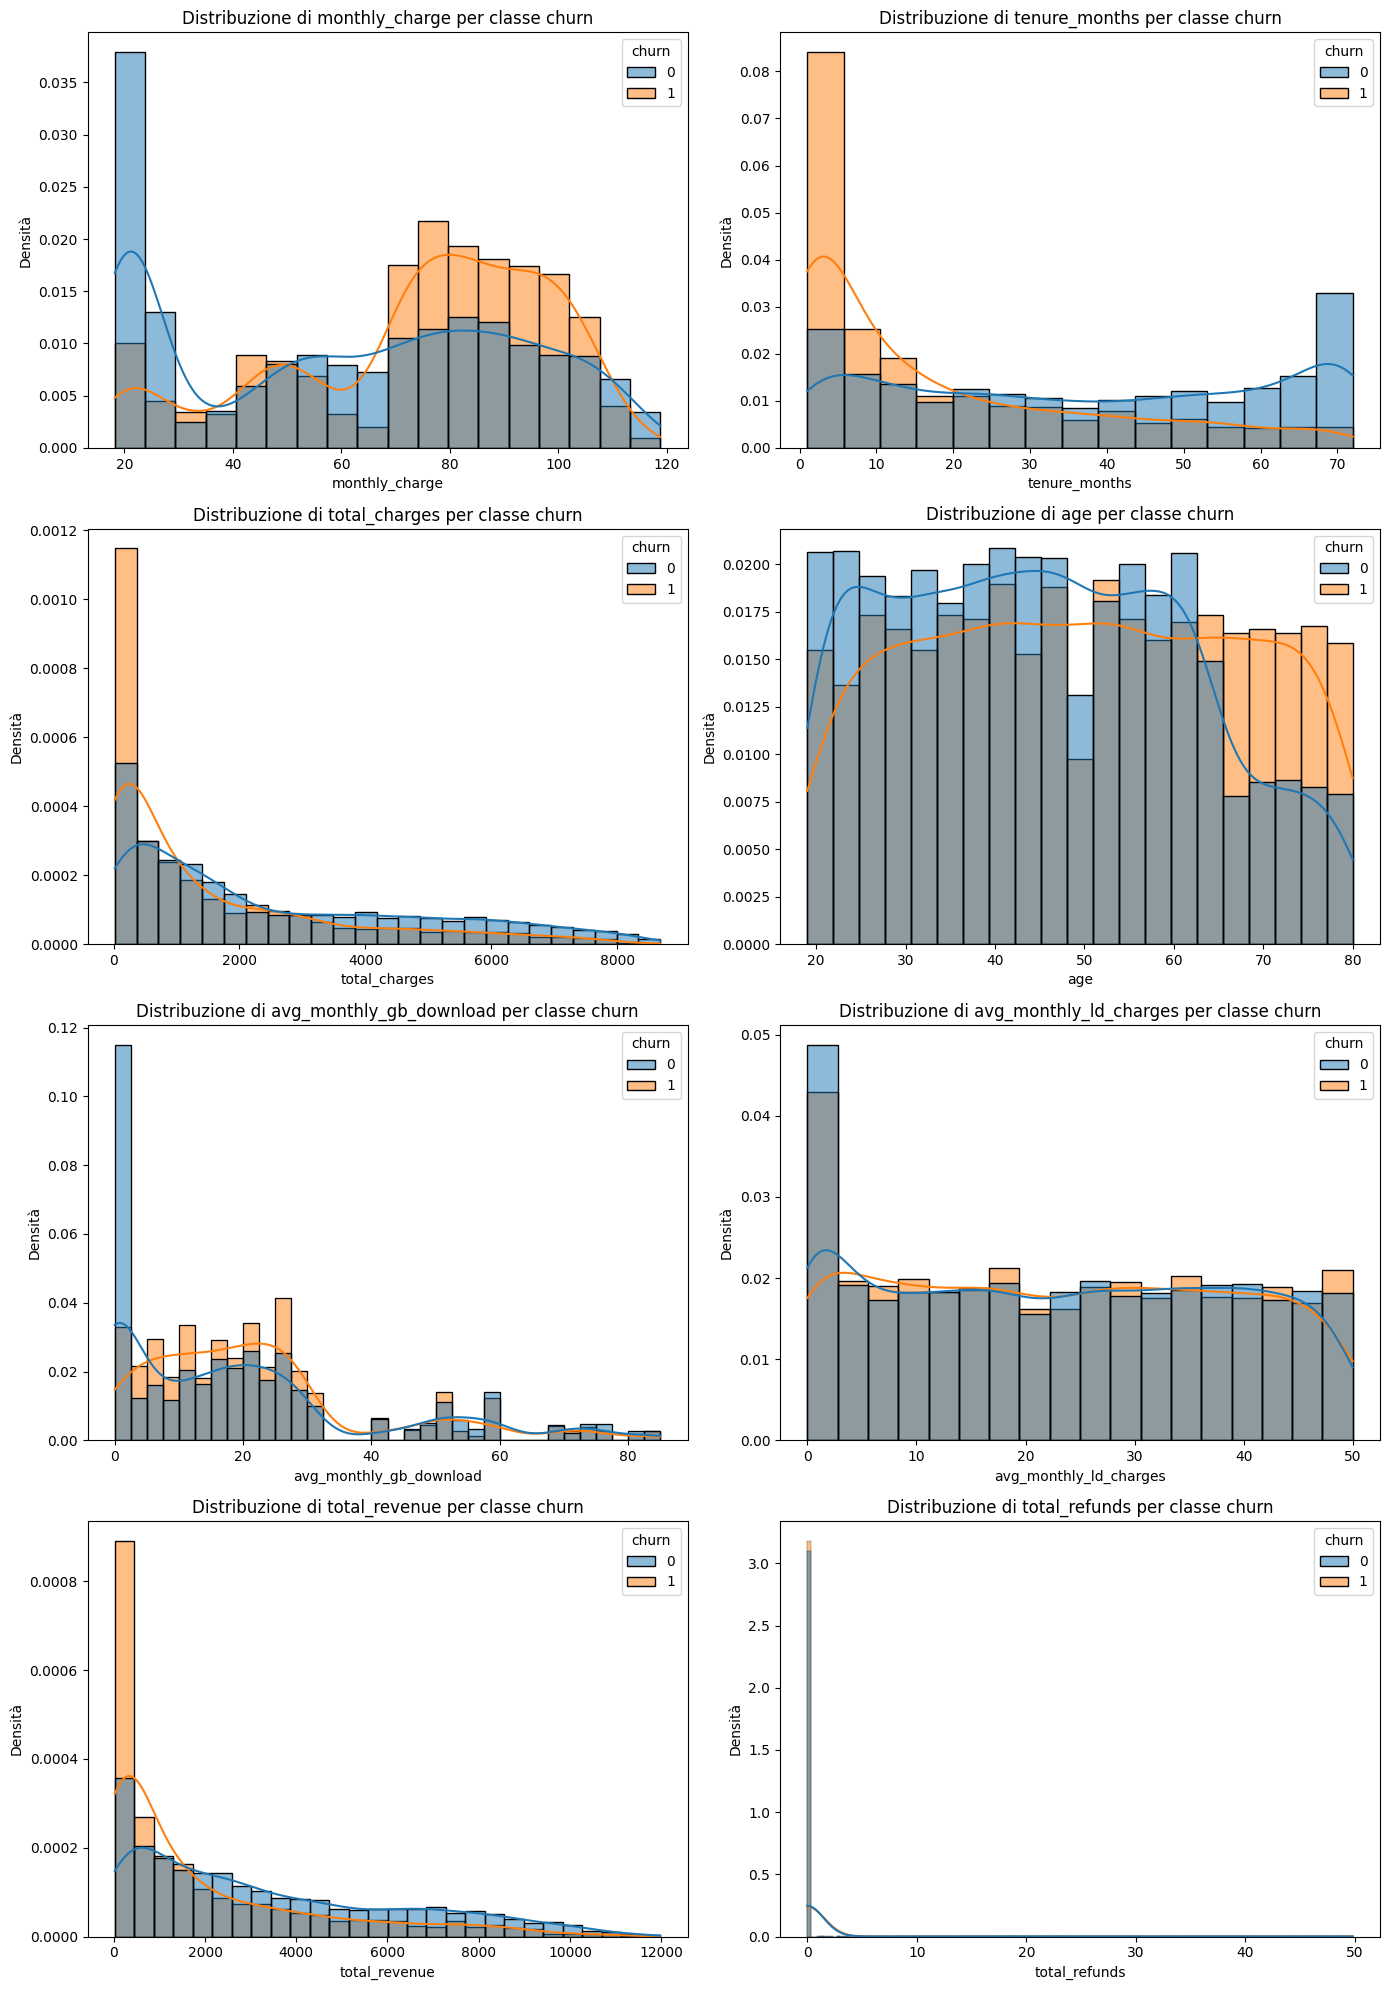

In [38]:
from src.visualization import plot_numeric_distributions

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us08_distribuzioni_numeriche.png"))

plot_numeric_distributions(
    df=df,
    variables=numeric_vars,
    target_col='churn',
    save_path=figures_path
)

### Osservazioni

- **monthly_charge**: i clienti churned tendono ad avere costi mensili più alti.
  Buon predittore.

- **tenure_months**: i clienti con tenure bassa churned molto di più. 
  Chi è cliente da poco tempo è più a rischio.

- **total_charges**: distribuzione simile a tenure. I clienti churned hanno 
  in media un totale addebitato inferiore perché se ne sono andati prima.

- **age**: le due distribuzioni si sovrappongono molto — variabile poco 
  discriminante da sola.

- **avg_monthly_gb_download**: verifica se i clienti con alto consumo dati 
  churned di più o di meno.

- **avg_monthly_ld_charges**: verifica se la spesa per chiamate a lunga 
  distanza distingue i due gruppi.

- **total_revenue**: simile a monthly_charge e tenure — attesa separazione netta.

- **total_refunds**: verifica se i clienti con più rimborsi tendono a churnare
  maggiormente — potrebbe indicare insoddisfazione.

## US-09 · Analisi delle Variabili Categoriche rispetto al Churn

L'obiettivo è quantificare il tasso di churn per le principali variabili categoriche,
al fine di identificare i segmenti di clientela a maggior rischio di abbandono.
Le variabili analizzate sono: `contract`, `internet_type`, `payment_method`, `offer`.

In [39]:
# Variabili categoriche di interesse
categorical_vars = ['contract', 'internet_type', 'payment_method', 'offer']

# Tasso di churn per categoria (groupby + mean sul target binario)
for var in categorical_vars:
    churn_rate = df.groupby(var)['churn'].mean().mul(100).round(1).sort_values(ascending=False)
    print(f"\n--- {var.upper()} ---")
    print(churn_rate.to_string())


--- CONTRACT ---
contract
Month-to-Month    45.8
One Year          10.7
Two Year           2.5

--- INTERNET_TYPE ---
internet_type
Fiber Optic    40.7
Cable          25.7
DSL            18.6
No Internet     7.4

--- PAYMENT_METHOD ---
payment_method
Mailed Check       36.9
Bank Withdrawal    34.0
Credit Card        14.5

--- OFFER ---
offer
Offer E     52.9
No Offer    27.1
Offer D     26.7
Offer C     22.9
Offer B     12.3
Offer A      6.7


In [40]:
import importlib
import src.visualization
importlib.reload(src.visualization)

<module 'src.visualization' from 'c:\\Users\\Giada Jenny Qafalia\\Desktop\\develhope\\Progetto_team\\telco-churn-ml\\src\\visualization.py'>

Grafico salvato in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\us09_churn_per_categoria.png


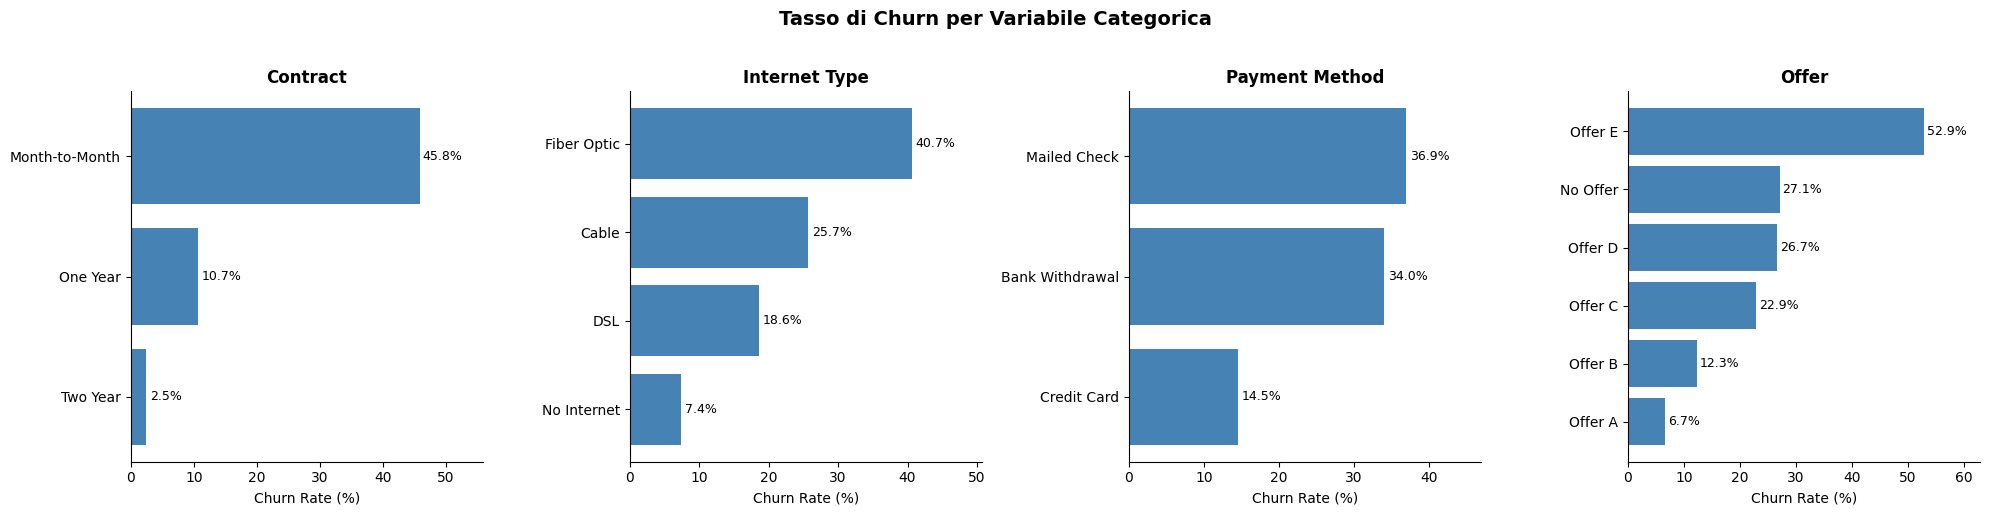

In [41]:
from src.visualization import plot_categorical_churn_rates

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us09_churn_per_categoria.png"))

plot_categorical_churn_rates(
    df=df,
    variables=categorical_vars,
    target_col='churn',
    save_path=figures_path
)

### Osservazioni

| Variabile | Categoria a maggior rischio | Churn Rate | Categoria a minor rischio | Churn Rate |
|---|---|---|---|---|
| Contract | Month-to-Month | 45.8% | Two Year | 2.5% |
| Internet Type | Fiber Optic | 40.7% | No Internet | 7.4% |
| Payment Method | Mailed Check | 36.9% | Credit Card | 14.5% |
| Offer | Offer E | 52.9% | Offer A | 6.7% |

**Contract**: la variabile più discriminante dell'analisi. I clienti con contratto 
mensile abbandonano a un tasso 18 volte superiore rispetto ai biennali (45.8% vs 2.5%). 
La fidelizzazione contrattuale è il principale fattore di retention identificato.

**Internet Type**: i clienti Fiber Optic mostrano il tasso di churn più alto (40.7%), 
nonostante — o forse a causa di — il servizio premium. Questo suggerisce aspettative 
più elevate e maggiore sensibilità al rapporto qualità/prezzo.

**Payment Method**: i clienti con pagamento automatico via carta di credito churned 
significativamente meno (14.5%) rispetto a chi paga con assegno cartaceo (36.9%). 
L'attrito del pagamento manuale potrebbe correlare con una minore fidelizzazione attiva.

**Offer**: Offer E presenta il tasso di churn più critico (52.9%), superiore persino 
ai clienti senza nessuna offerta (27.1%). Questo dato richiede un'analisi dedicata 
da parte del team commerciale: l'offerta potrebbe attrarre segmenti ad alto rischio 
o generare aspettative non mantenute. Offer A è invece la più efficace (6.7%).

**Implicazione strategica**: le leve più azionabili per la retention sono la 
conversione dei contratti mensili verso formule pluriennali e la revisione di Offer E.